# 手寫阿拉伯數字辨識 完整版

## 載入套件

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from skimage.transform import resize
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchinfo import summary
from torchvision import transforms
from torchvision.datasets import MNIST
import torchmetrics

## 設定參數

In [2]:
PATH_DATASETS = "data" # 預設路徑
BATCH_SIZE = 1024  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 步驟1：載入 MNIST 手寫阿拉伯數字資料

In [3]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])


# 下載 MNIST 手寫阿拉伯數字 訓練資料
train_ds = MNIST(PATH_DATASETS, train=True, download=True, transform=transform)

# 下載測試資料
test_ds = MNIST(PATH_DATASETS, train=False, download=True, transform=transform)

# 訓練/測試資料的維度
print(train_ds.data.shape, test_ds.data.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


In [4]:
# 訓練資料前10筆圖片的數字
train_ds.targets[:10]

tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])

In [5]:
# 顯示第1張圖片內含值
train_ds.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

## 使用 DataLoader 讀取資料，transform 才會發生作用

In [6]:
# 建立 DataLoader
train_loader = DataLoader(train_ds, batch_size=1)
# 一次取一『批』資料
data1: torch.Tensor
data1, target = next(iter(train_loader))
print(data1.shape, target)

torch.Size([1, 1, 28, 28]) tensor([5])


In [7]:
data1

tensor([[[[-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.424

In [8]:
# 將非0的數字轉為1，顯示第1張圖片
data = train_ds.data[0].clone()
data[data > 0] = 1
data = data.numpy()

# 將轉換後二維內容顯示出來，隱約可以看出數字為 5
text_image: list[str] = []
for i in range(data.shape[0]):
    text_image.append(''.join(data[i].astype(str)))
text_image

['0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000001111111111110000',
 '0000000011111111111111110000',
 '0000000111111111111111100000',
 '0000000111111111110000000000',
 '0000000011111110110000000000',
 '0000000001111100000000000000',
 '0000000000011110000000000000',
 '0000000000011110000000000000',
 '0000000000001111110000000000',
 '0000000000000111111000000000',
 '0000000000000011111100000000',
 '0000000000000001111100000000',
 '0000000000000000011110000000',
 '0000000000000011111110000000',
 '0000000000001111111100000000',
 '0000000000111111111000000000',
 '0000000011111111110000000000',
 '0000001111111111000000000000',
 '0000111111111100000000000000',
 '0000111111110000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000']

In [9]:
# 將非0的數字轉為1，顯示第2張圖片
data = train_ds.data[1].clone()
data[data > 0] = 1
data = data.numpy()

# 將轉換後二維內容顯示出來，隱約可以看出數字為 5
text_image: list[str] = []
for i in range(data.shape[0]):
    text_image.append(''.join(data[i].astype(str)))
text_image

['0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000001111100000000',
 '0000000000000011111100000000',
 '0000000000000111111111000000',
 '0000000000011111111111000000',
 '0000000000011111111111000000',
 '0000000000111111111111000000',
 '0000000001111111110011100000',
 '0000000011111100000011100000',
 '0000000111111100000011100000',
 '0000000111100000000011100000',
 '0000000111000000000011100000',
 '0000001111000000000011100000',
 '0000001111000000001111100000',
 '0000001110000000011111000000',
 '0000001110000000111100000000',
 '0000001110000001111000000000',
 '0000001111111111111000000000',
 '0000001111111111100000000000',
 '0000001111111110000000000000',
 '0000000111111100000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000']

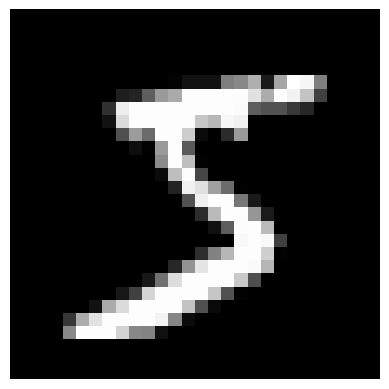

In [10]:
# 顯示第1張圖片圖像
# 第一筆資料
X = train_ds.data[0]

# 繪製點陣圖，cmap='gray':灰階
plt.imshow(X.reshape(28, 28), cmap='gray')

# 隱藏刻度
plt.axis('off')

# 顯示圖形
plt.show()

## 步驟2：資料清理，此步驟無需進行

## 步驟3：進行特徵工程，將特徵縮放成(0, 1)之間

In [21]:
# train_ds.data = train_ds.data / 255.0
# test_ds.data = test_ds.data / 255.0

## 步驟4：資料分割，此步驟無需進行，載入MNIST資料時，已經切割好了

## 步驟5：建立模型結構

In [ ]:
# 建立模型
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256),
    nn.Dropout(0.2),
    nn.Linear(256, 10),
    # 使用nn.CrossEntropyLoss()時，不需要將輸出經過softmax層，否則計算的損失會有誤
    # nn.Softmax(dim=1),
).to(device)

## 步驟6：結合訓練資料及模型，進行模型訓練

In [ ]:
epochs = 5
lr = 0.1

# 建立 DataLoader
train_loader = DataLoader(train_ds, batch_size=600)

# 設定優化器(optimizer)
# optimizer = optim.Adam(model.parameters(), lr=lr)
optimizer = optim.Adadelta(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

model.train()
loss_list: list[float] = []
data_count = len(train_ds.data)
for epoch in range(1, epochs + 1):
    data: torch.Tensor
    target: torch.Tensor
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        #         if batch_idx == 0 and epoch == 1: print(data[0])

        output: torch.Tensor = model(data)
        loss = criterion.forward(output, target)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch_idx % 10 == 0:
            loss_list.append(loss.item())
            batch = batch_idx * len(data)
            percentage = 100.0 * batch_idx / len(train_loader)
            print(f'Epoch {epoch}: [{batch:5d} / {data_count}] ({percentage:.0f} %)  Loss: {loss.item():.6f}')

Epoch 1: [    0 / 60000] (0 %)  Loss: 2.390076
Epoch 1: [ 6000 / 60000] (10 %)  Loss: 1.335167
Epoch 1: [12000 / 60000] (20 %)  Loss: 1.004936
Epoch 1: [18000 / 60000] (30 %)  Loss: 0.749640
Epoch 1: [24000 / 60000] (40 %)  Loss: 0.671243
Epoch 1: [30000 / 60000] (50 %)  Loss: 0.657162
Epoch 1: [36000 / 60000] (60 %)  Loss: 0.531972
Epoch 1: [42000 / 60000] (70 %)  Loss: 0.584079
Epoch 1: [48000 / 60000] (80 %)  Loss: 0.397419
Epoch 1: [54000 / 60000] (90 %)  Loss: 0.425760
Epoch 2: [    0 / 60000] (0 %)  Loss: 0.412634
Epoch 2: [ 6000 / 60000] (10 %)  Loss: 0.311544
Epoch 2: [12000 / 60000] (20 %)  Loss: 0.451423
Epoch 2: [18000 / 60000] (30 %)  Loss: 0.325427
Epoch 2: [24000 / 60000] (40 %)  Loss: 0.377138
Epoch 2: [30000 / 60000] (50 %)  Loss: 0.396497
Epoch 2: [36000 / 60000] (60 %)  Loss: 0.356375
Epoch 2: [42000 / 60000] (70 %)  Loss: 0.471486
Epoch 2: [48000 / 60000] (80 %)  Loss: 0.299336
Epoch 2: [54000 / 60000] (90 %)  Loss: 0.351834
Epoch 3: [    0 / 60000] (0 %)  Loss: 0.31

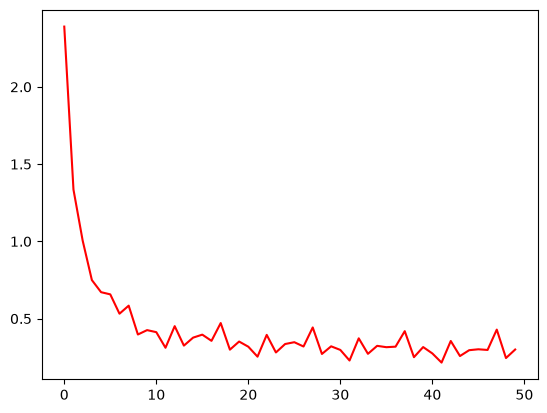

In [13]:
# 對訓練過程的損失繪圖
plt.plot(loss_list, 'r')

## 步驟7：評分(Score Model)

In [ ]:
# 建立 DataLoader
test_loader = DataLoader(test_ds, shuffle=False)

model.eval()
test_loss = 0.0
correct = 0
with torch.no_grad():
    data: torch.Tensor
    target: torch.Tensor
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output: torch.Tensor = model(data)

        # sum up batch loss
        test_loss += criterion.forward(output, target).item()

        # 預測
        pred = output.argmax(dim=1, keepdim=True)

        # 正確筆數
        correct += pred.eq(target.view_as(pred)).sum().item()

# 平均損失
data_count = len(test_ds.data)
test_loss /= data_count
# 顯示測試結果
percentage = 100.0 * correct / data_count
print(f'平均損失: {test_loss:.4f}, 準確率: {correct}/{data_count} ({percentage:.0f}%)\n')

平均損失: 0.2895, 準確率: 9177/10000 (92%)



In [15]:
# 實際預測 20 筆資料
predictions: list[str] = []
with torch.no_grad():
    data: torch.Tensor
    for i in range(20):
        data = test_ds[i][0]
        data = data.reshape(1, *data.shape).to(device)
        output = torch.argmax(model(data), dim=-1)
        predictions.append(str(output.item()))

# 比對
print('actual    :', test_ds.targets[0:20].numpy())
print('prediction: ', ' '.join(predictions[0:20]))

actual    : [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
prediction:  7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4


In [16]:
# 顯示第 9 筆的機率
i = 8
data: torch.Tensor = test_ds[i][0]
data = data.reshape(1, *data.shape).to(device)
# print(data.shape)
predictions = torch.softmax(model(data), dim=1)
print(f'0~9預測機率: {np.around(predictions.cpu().detach().numpy(), 2)}')
print(f'0~9預測機率: {np.argmax(predictions.cpu().detach().numpy(), axis=-1)}')

0~9預測機率: [[0.   0.   0.   0.   0.01 0.01 0.98 0.   0.   0.  ]]
0~9預測機率: [6]


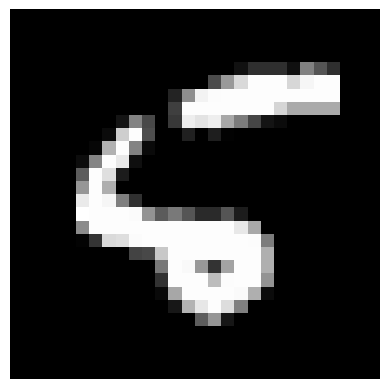

In [17]:
# 顯示第 9 筆圖像
X2: torch.Tensor = test_ds[i][0]
plt.imshow(X2.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()

## 步驟8：評估，暫不進行

## 步驟9：模型佈署

In [18]:
# 模型存檔
torch.save(model, 'model.pt')

# 模型載入
model: nn.Sequential = torch.load('model.pt', weights_only=False)

## 步驟10：新資料預測

In [19]:
# 使用小畫家，繪製 0~9，實際測試看看
# 讀取影像並轉為單色
for i in range(10):
    uploaded_file = f'./myDigits/{i}.png'
    image1 = io.imread(uploaded_file, as_gray=True)

    # 縮為 (28, 28) 大小的影像
    image_resized = resize(image1, (28, 28), anti_aliasing=True)
    X1 = np.asarray(image_resized).reshape(1, 28, 28)  # / 255.0

    # 反轉顏色，顏色0為白色，與 RGB 色碼不同，它的 0 為黑色
    X1 = torch.FloatTensor(1 - X1).to(device)

    # 預測
    predictions = torch.softmax(model(X1), dim=1)
    # print(np.around(predictions.cpu().detach().numpy(), 2))
    print(f'actual/prediction: {i} {np.argmax(predictions.detach().cpu().numpy())}')

actual/prediction: 0 0
actual/prediction: 1 1
actual/prediction: 2 2
actual/prediction: 3 0
actual/prediction: 4 4
actual/prediction: 5 5
actual/prediction: 6 6
actual/prediction: 7 3
actual/prediction: 8 8
actual/prediction: 9 8
